In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'texas_statewide_pipelines'
collection_id = 'vector-texas-statewide-pipelines'

# Stac collection title
collection_title = 'Texas Statewide Pipelines'

# Stac collection description
description = """Statewide Pipelines.
Texas Department of Transportation.
Statewide oil and gas pipelines provided by the Texas Railroad Commission.
https://gis-txdot.opendata.arcgis.com/datasets/TXDOT::statewide-pipelines/explore"""

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'timestamp'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'OBJECTID'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 1e5

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

filepath = '/data/vector/Statewide_Pipelines/a3e16b20-fa9b-42ab-af7f-c05897ba68b8202046-1-17fsv4b.vael.shp'
gdf_complete = geopandas.read_file(filepath)
gdf_complete[dt_col] = datetime(2022, 10, 5, tzinfo=pytz.utc) # Last update

assert(~gdf_complete[id_col].duplicated().any())

gdf_complete.tail(2)

CPU times: total: 1min 22s
Wall time: 2min 17s


,OBJECTID,TPMS_ID,OPER_LINK,OPS_ID,P5_NUM,OPER_NM,SYS_NM,SUBSYS_NM,T4PERMIT,DIAMETER,...,COUNTY,COM_CARRIE,PLINE_ID,SYS_ID,NPMS_SYS_I,ALBERS_MIL,LENGTH,Shape__Len,geometry,timestamp
477759,477760,2303576,0,0,253368,ENTERPRISE PRODUCTS OPERATINGLLC,BIG WELLS GATHERING SYSTEM,None,00832,8.63,...,507,N,None,000000,0,0.058982,0.0,94.984127,"LINESTRING (-99.55325 28.69086, -99.55319 28.6...",2022-10-05 00:00:00+00:00
477760,477761,3323316,0,0,655849,PERMICO MIDSTREAM PARTNERS LLC,COMPANERO,COMPANERO,10077,24.00,...,507,Y,None,966581,0,52.149612,0.0,83925.002441,"LINESTRING (-100.11203 28.98046, -100.10937 28...",2022-10-05 00:00:00+00:00


In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x225e5b55990>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'texas_statewide_pipelines',
 'collection_id': 'vector-texas-statewide-pipelines',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/texas_statewide_pipelines',
 'grid_directory': 'data/vectorstore/texas_statewide_pipelines/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/texas_statewide_pipelines/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/texas_statewide_pipelines/grid=World(4326)/index',
 'dt_col': 'timestamp',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'OBJECTID',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['timestamp', 'OBJECTID'],
 'max_level': 26,
 'target_level': 14,
 'max_depth': 14,


# Chunked successive ingestion

In [4]:
%%time
n_chunks = 1
for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
    print('Chunk', i)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)


Chunk 0
df_root 477761
Time for indexing the root of each unique geometry in seconds 5.706
distributed over 7 partitions
Time for creating partitions in seconds 2.773
Time for writing GeoDataFrame to GeoParquet partitions 8.835
CPU times: total: 9.19 s
Wall time: 14.8 s


In [5]:
%%time
vs.unify_schemas()

Time for unify_schemas 1.375
CPU times: total: 766 ms
Wall time: 1.37 s


In [6]:
%%time
vs.defrag()

Time for defragging 8.083
CPU times: total: 4.12 s
Wall time: 8.08 s


In [7]:
%%time
vs.repartition({})

level 4
source partition          target partition          records stay    records move   
level 5
source partition          target partition          records stay    records move   
level 6
source partition          target partition          records stay    records move   
level 7
source partition          target partition          records stay    records move   
level 8
source partition          target partition          records stay    records move   
level 9
source partition          target partition          records stay    records move   
level 10
source partition          target partition          records stay    records move   
level 11
source partition          target partition          records stay    records move   
level 12
source partition          target partition          records stay    records move   
level 13
source partition          target partition          records stay    records move   
level 14
source partition          target partition          records stay   

In [8]:
%%time
vs.defrag()

Time for defragging 6.817
CPU times: total: 3.69 s
Wall time: 6.82 s


In [9]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [10]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory)
ddf

CPU times: total: 0 ns
Wall time: 67 ms


,OBJECTID,TPMS_ID,OPER_LINK,OPS_ID,P5_NUM,OPER_NM,SYS_NM,SUBSYS_NM,T4PERMIT,DIAMETER,COMMODITY1,COMMODITY2,COMMODITY3,CMDTY_DESC,INTERSTATE,STATUS_CD,QUALITY_CD,SYSTYPE,COUNTY,COM_CARRIE,PLINE_ID,SYS_ID,NPMS_SYS_I,ALBERS_MIL,LENGTH,Shape__Len,geometry,timestamp,_root,grid,spatial_partition
npartitions=7,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,int64,int64,int64,object,object,object,object,object,float64,object,object,object,object,object,object,object,object,object,object,object,object,int64,float64,float64,float64,geometry,"datetime64[us, UTC]",object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

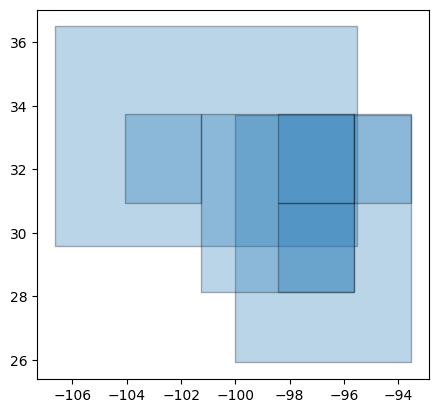

In [11]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [12]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('claimed_access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('claimed_secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('claimed_endpoint_url', '')
# S3 access url
private_endpoint_url = os.getenv('claimed_private_endpoint_url', '')
# S3 bucket
bucket = os.getenv('claimed_bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

In [13]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [14]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [15]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [16]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

removing remote_filepaths ['claimed-test/vectorstore/texas_statewide_pipelines/grid=World(4326)/geoparquet/spatial_partition=0q0213/ef6e4445fa53483d9b63926e44b1cbbf.parquet', 'claimed-test/vectorstore/texas_statewide_pipelines/grid=World(4326)/geoparquet/spatial_partition=0q0213033/726f11735fe8406882c8f6d42bc7dadf.parquet', 'claimed-test/vectorstore/texas_statewide_pipelines/grid=World(4326)/geoparquet/spatial_partition=0q02131/1526d545d60a46c6a6fe1dba6ae63bcd.parquet', 'claimed-test/vectorstore/texas_statewide_pipelines/grid=World(4326)/geoparquet/spatial_partition=0q021312/eadc3c6efb7743598f3c6b4f10ef7317.parquet', 'claimed-test/vectorstore/texas_statewide_pipelines/grid=World(4326)/geoparquet/spatial_partition=0q0213121/961b413bbcda469cae0e55081c924bf0.parquet', 'claimed-test/vectorstore/texas_statewide_pipelines/grid=World(4326)/geoparquet/spatial_partition=0q0213123/7e60755acd5a4f94a9da88da9c0f1c1e.parquet', 'claimed-test/vectorstore/texas_statewide_pipelines/grid=World(4326)/geop

In [17]:
vs.stac_json_folder_submitted

'data/vectorstore/texas_statewide_pipelines/grid=World(4326)/stac/submitted'

In [18]:
vs.stac_url

'https://stac-fastapi-sqlalchemy-nasageospatial-dev.cash.sl.cloud9.ibm.com'

In [19]:
vs.collection_id

'vector-texas-statewide-pipelines'